## 1. Imports and load data

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import random

from scipy import stats
from scipy.stats import pearsonr
from wordfreq import zipf_frequency

from flow_tree_utils import (
    steiger_z_test,
    get_matched_random_walk,
    generate_flow_tree_from_trajs,
    plot_flow_tree,
)

### Load wikispeedia data, etc

In [2]:
### Load articles and categories
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#":
            continue

        article_names.append(line)
print(f"{len(article_names)} nodes/articles loaded.")

# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(
    f"{data_path}/links.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(13)],
)
print(f"{len(edges_df)} edges/hyperlinks loaded.")

wikiG = nx.DiGraph()
wikiG.add_edges_from(zip(edges_df.linkSource, edges_df.linkTarget))
print(wikiG)

4604 nodes/articles loaded.
119881 edges/hyperlinks loaded.
DiGraph with 4592 nodes and 119881 edges


In [3]:
### Load trajectories
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]


def get_path_len(x):
    return len(x.split(";"))


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(
    f"{data_path}/paths_finished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(16)],
)
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, -1)
)
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = [
    "hashedIpAddress",
    "timestamp",
    "durationInSec",
    "path",
    "target",
    "type",
]
unfinished_trajs_df = pd.read_csv(
    f"{data_path}/paths_unfinished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(17)],
)
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
# trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
# trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)

# don't want multiple attempts for each person
print(f"{trajs_df.shape[0]} trajectories before dupes removed")
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartAt", "target"])

print(f"Final data has {trajs_df.shape[0]} trajectories")
print(
    f"\twith {len(trajs_df.StartAt.unique())} unique starts and {len(trajs_df.EndAt.unique())} unique ends"
)
print(f"\tand {len(trajs_df.hashedIpAddress.unique())} unique players")


def process_path(path):
    # Longest backclick sequence is 22 <;<;<;<;<;<;<;<;<;<;<;<;<;<;< + more
    # print(path)
    assert ";<" * 23 not in path

    for i in range(21, 0, -1):
        backtrack_seq = "<" + ";<" * i
        if backtrack_seq in path:
            path = path.replace(backtrack_seq, f"<{i + 1}")

    split_path = path.split(";")
    real_nodes = []
    for i, node in enumerate(split_path):
        if "<" in node:
            bktrk = 1 if node == "<" else int(node[1:])
            node = real_nodes[i - bktrk - 1]
        real_nodes.append(node)

    return real_nodes


trajs_df["traj"] = trajs_df["path"].apply(process_path)
trajs_df["StartEnd"] = trajs_df["StartAt"] + "__" + trajs_df["EndAt"]

trajs_df["accuracy"] = trajs_df.groupby("StartEnd")["finished"].transform("mean")
trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "accuracy", "avg_rating"]].head()

76193 trajectories before dupes removed
Final data has 70770 trajectories
	with 4168 unique starts and 3997 unique ends
	and 20868 unique players


,StartEnd,traj,accuracy,avg_rating
0,14th_century__African_slave_trade,"[14th_century, 15th_century, 16th_century, Pac...",0.428571,3.0
1,14th_century__African_slave_trade,"[14th_century, Europe, Africa, Atlantic_slave_...",0.428571,3.0
2,14th_century__African_slave_trade,"[14th_century, Niger, Nigeria, British_Empire,...",0.428571,3.0
3,14th_century__Greece,"[14th_century, Renaissance, Ancient_Greece, Gr...",1.000000,NaN
4,14th_century__John_F._Kennedy,"[14th_century, Italy, Roman_Catholic_Church, H...",1.000000,3.0


## 2. Helper fns
to make below less gross

In [4]:
node_counts = {}
for trajectory in trajs_df.traj:
    for node in trajectory:
        node_counts[node] = node_counts.get(node, 0) + 1

stop_words = set(["a", "an", "the", "and", "for", "of"])

node_indegrees = {}
node_outdegrees = {}
node_zipf_frequencies = {}
for node in node_counts:
    if node in wikiG:
        node_indegrees[node] = wikiG.in_degree(node)
        node_outdegrees[node] = wikiG.out_degree(node)
        node_zipf_frequencies[node] = np.mean(
            [
                zipf_frequency(word, "en")
                for word in node.split("_")
                if word not in stop_words
            ]
        )


# find most common nodes
def find_k_most_x_nodes(
    node_value_dict, k=100, restrict_to=None, actually_most=True, verbose_str=None
):
    if restrict_to is None:
        restrict_to = node_value_dict.keys()
    most_x_nodes = sorted(
        [x for x in restrict_to],
        key=lambda x: node_value_dict[x],
        reverse=actually_most,
    )[:k]

    if verbose_str:
        print(
            f"{'Most' if actually_most else 'Least'} {verbose_str} node is {most_x_nodes[0]} with {node_value_dict[most_x_nodes[0]]}; "
            f"{k}th {'most' if actually_most else 'least'} is {most_x_nodes[-1]} with {node_value_dict[most_x_nodes[-1]]}"
        )
    return most_x_nodes

In [15]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),  # ← origin, not the data mean
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        **kwargs,
    )
    # no set_angle() — handled by the transform below

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    trans = (
        transforms.Affine2D()
        .rotate_deg(45)  # ← always 45° for the Pearson formulation
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)  # ← translation happens exactly once
    )
    ellipse.set_transform(trans + ax.transData)
    return ax.add_patch(ellipse)

In [5]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# pip install "tokenizers<0.22" --force-reinstall
model_name = "bert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)


def embed(text):
    tokens = tok(text.replace("_", " "), return_tensors="pt", truncation=True)
    out = model(**tokens)
    # mean pooling
    emb = out.last_hidden_state.mean(dim=1)
    return emb.detach()


def cosine(a, b):
    return F.cosine_similarity(a, b).item()


def get_topic_distance(topic1, topic2):
    return cosine(embed(topic1), embed(topic2))


get_topic_distance("the_dog", "the_cat")

0.9181366562843323

In [6]:
embeddings_dict = {node: embed(node) for node in node_counts}

In [7]:
degree_cache = {}
zipf_cache = {}
cosine_cache = {}

In [8]:
def get_weighted_matched_random_walk(
    G, start_node, walk_length, weights, degree_cache=degree_cache
):
    trajectory = [start_node]
    current_node = start_node

    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))

        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        elif len(neighbors) == 1:
            current_node = neighbors[0]
        else:
            # if current_node in degree_cache:
            #     # print("using cache")
            #     these_weights = degree_cache[current_node]
            # else:
            # print("adding to cache", current_node)
            these_weights = [weights[n] for n in neighbors]
            # degree_cache[current_node] = these_weights
            try:
                current_node = random.choices(neighbors, these_weights, k=1)[0]
            except:
                print(these_weights)
        trajectory.append(current_node)

    return trajectory


def get_targeted_matched_random_walk(G, start_node, target, walk_length):
    trajectory = [start_node]
    current_node = start_node

    # print(start_node, target)
    # print(walk_length)

    # TODO: this should be based on similariyt to target youa re so stupid
    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))
        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        else:
            if current_node in cosine_cache:
                # print("using cache")
                weights = cosine_cache[current_node]
            else:
                weights = []
                for n in neighbors:
                    w1 = embeddings_dict.get(n, embed(n))
                    if n not in embeddings_dict:
                        embeddings_dict[n] = w1

                    w2 = embeddings_dict.get(current_node, embed(current_node))
                    if current_node not in embeddings_dict:
                        embeddings_dict[current_node] = w2
                    dist = cosine(w1, w2)
                    weights.append(dist)
                cosine_cache[current_node] = weights
                print("added to cache", current_node)

            current_node = random.choices(neighbors, weights, k=1)[0]
        trajectory.append(current_node)
    return trajectory

In [9]:
degree_centrality = nx.degree_centrality(wikiG)
print("Degree Centrality:", degree_centrality)

word_frequency_centrality = {}
for node in wikiG.nodes():
    word_frequency_centrality[node] = np.mean(
        [zipf_frequency(word, "en") for word in node.split("_")]
    )
print("Word Frequency Centrality:", word_frequency_centrality)

Degree Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.0021781746896101066, 'Columba': 0.005009801786103245, 'D%C3%A1l_Riata': 0.006970159006752342, 'Great_Britain': 0.0468307558266173, 'Ireland': 0.08494881289479417, 'Isle_of_Man': 0.021128294489218036, 'Monarchy': 0.04356349379220214, 'Orkney': 0.013286865606621652, 'Picts': 0.00958396863428447, 'Scotland': 0.0980178610324548, 'Wales': 0.0490089305162274, '%C3%85land': 0.004138531910259203, '20th_century': 0.08690917011544326, 'Baltic_Sea': 0.024177739054672187, 'Crimean_War': 0.012197778261816599, 'Currency': 0.06817686778479634, 'Euro': 0.03201916793726857, 'European_Union': 0.08298845567414508, 'Finland': 0.04966238292311043, 'League_of_Nations': 0.029840993247658463, 'List_of_countries_by_system_of_government': 0.09867131343933784, 'Nationality': 0.00936615116532346, 'Parliamentary_system': 0.02940535830973644, 'Police': 0.021128294489218036, 'Russia': 0.13613591810063166, 'Stockholm': 0.013722500544543673, 'Sweden': 0.0847309

In [10]:
def make_traj_dict(node_list, trajs_df, min_path_length=5):
    traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(len(traj) - min_path_length - 1):  # want min path length 5?
            if traj[i] in node_list:
                traj_dict[traj[i]].append(traj[i : i + min_path_length])
    return traj_dict


def make_rev_traj_dict(node_list, trajs_df, min_path_length=5):
    rev_traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(min_path_length, len(traj)):  # want min path length 7?
            if traj[i] in node_list:
                rev_traj = [x for x in reversed(traj[i - min_path_length : i])]
                rev_traj_dict[traj[i]].append(rev_traj)
    return rev_traj_dict


def sample_flow_trees_from_traj_dict(traj_dict, wikiG, k_fold=5, traj_per_tree=20):
    flow_tree_dict = {}
    for node in traj_dict:
        trees = []
        random_trees, weighted_random_trees, targeted_random_trees = [], [], []
        for _ in range(k_fold):
            sampled_trajs = traj_dict[node]
            if len(sampled_trajs) > traj_per_tree:
                sampled_indices = np.random.choice(
                    len(sampled_trajs), size=traj_per_tree, replace=False
                )
                sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
            # else:
            #     print(len(sampled_trajs))
            G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
            new_G = nx.relabel.convert_node_labels_to_integers(
                G, first_label=0, ordering="default"
            )
            trees.append(new_G)

            # using random data
            if sampled_trajs[0][0] in wikiG:
                # print("making random trajs")
                random_trajs = [
                    get_matched_random_walk(
                        wikiG, sampled_trajs[0][0], len(sampled_trajs[i])
                    )
                    for i in range(len(sampled_trajs))
                ]
                random_weighted_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        degree_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]
                # print("dc", len(degree_cache))

                random_semantic_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        word_frequency_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]

                # [get_targeted_matched_random_walk(
                #     wikiG, sampled_trajs[0][0], sampled_trajs[i][-1], len(sampled_trajs[i])
                # ) for i in range(len(sampled_trajs))]
                # print("cc", len(cosine_cache))
                # print("done")

                random_G = generate_flow_tree_from_trajs(random_trajs, END_NODE="1")
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                random_trees.append(new_G)

                weighted_random_G = generate_flow_tree_from_trajs(
                    random_weighted_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    weighted_random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                weighted_random_trees.append(new_G)

                random_G = generate_flow_tree_from_trajs(
                    random_semantic_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                targeted_random_trees.append(new_G)

                # print("done making trees")
        flow_tree_dict[node] = {
            "human": trees,
            "random": random_trees,
            "weighted_random": weighted_random_trees,
            "targeted_random": targeted_random_trees,
        }
    return flow_tree_dict

In [11]:
def plot_some_from_flow_tree_dict(flow_tree_dict, title_str=""):
    n_cols = 6
    fig, axes = plt.subplots(4, n_cols, figsize=(20, 8))
    for j, node in enumerate(flow_tree_dict):
        G = flow_tree_dict[node]["human"][0]
        ax = axes[0][j]
        plot_flow_tree(G, f"HUMAN init at {node}", ax, just_edges=True, no_title=False)

        random_G = flow_tree_dict[node]["random"][0]
        ax = axes[1][j]
        plot_flow_tree(
            random_G, f"RANDOM init at {node}", ax, just_edges=True, no_title=False
        )

        random_G = flow_tree_dict[node]["weighted_random"][0]
        ax = axes[2][j]
        plot_flow_tree(
            random_G,
            f"WEIGHTED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        random_G = flow_tree_dict[node]["targeted_random"][0]
        ax = axes[3][j]
        plot_flow_tree(
            random_G,
            f"TARGETED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        if j == n_cols - 1:
            break
    plt.suptitle(title_str)
    plt.tight_layout()
    plt.show()

In [12]:
def make_flow_tree_dict_from_node_list(
    node_list,
    trajs_df,
    min_path_length=7,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=20,
    plot_title_str=None,
):
    traj_dict = make_traj_dict(node_list, trajs_df, min_path_length=min_path_length)
    flow_tree_dict = sample_flow_trees_from_traj_dict(
        traj_dict, wikiG, k_fold=k_fold, traj_per_tree=traj_per_tree
    )

    if plot_title_str:
        plot_some_from_flow_tree_dict(flow_tree_dict, title_str=plot_title_str)

    return flow_tree_dict

In [13]:
def tree_depth(graph, root=0):
    depths = nx.single_source_shortest_path_length(graph, root)
    return max(depths.values())


def branching_factor(graph):
    branching_factors = [
        len(list(graph.neighbors(node)))
        for node in graph.nodes()
        if graph.degree(node) != 1
    ]
    return np.mean(branching_factors)


def root_degree(graph, root=0):
    return graph.degree[root]


def extract_tree_features(G, root=0):
    num_nodes = G.number_of_nodes()
    num_leaves = sum(1 for node in G.nodes() if G.degree(node) == 1)
    depth = tree_depth(G, root)
    diameter = nx.diameter(G)
    bf = branching_factor(G)
    rd = root_degree(G, root)

    return [
        num_nodes,
        num_leaves,
        depth,
        diameter,
        bf,
        rd,
    ]


def run_ttests_on_flow_tree_groups(
    group1_trees,
    group2_trees,
    normalise=False,
    group1_name="Group 1",
    group2_name="Group 2",
):
    results_df = pd.DataFrame(
        columns=[
            "group1_name",
            "group2_name",
            "group1_mean",
            "group2_mean",
            "group1_var",
            "group2_var",
            "group1_n",
            "group2_n",
            "statistic",
            "p_value",
            "metric",
            "notes",
        ]
    )

    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "diameteravg_branching_factor",
        "root_degree",
    ]

    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)

            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (
                    feature_max - feature_min
                )
                group2_feature = (group2_feature - feature_min) / (
                    feature_max - feature_min
                )

        # T-test
        t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
        results_df.loc[len(results_df)] = {
            "group1_name": group1_name,
            "group2_name": group2_name,
            "group1_mean": np.mean(group1_feature),
            "group2_mean": np.mean(group2_feature),
            "group1_var": np.var(group1_feature),
            "group2_var": np.var(group2_feature),
            "group1_n": len(group1_feature),
            "group2_n": len(group2_feature),
            "statistic": t_stat,
            "p_value": p_val,
            "metric": feature_name,
            "notes": f"Comparing flow tree {feature_name} between {group1_name} and {group2_name}",
        }

    return results_df, group1_features, group2_features

## 3. Compute nodes based on statistics

In [14]:
big_k = 500
small_k = 50
most_common_nodes = find_k_most_x_nodes(node_counts, k=big_k, verbose_str="common")
most_indegree_nodes = find_k_most_x_nodes(
    node_indegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="indegree"
)
least_indegree_nodes = find_k_most_x_nodes(
    node_indegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="indegree",
)
most_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="outdegree"
)
least_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="outdegree",
)

print()
print(
    "Most outdegree, most indegree overlap",
    len(set(most_indegree_nodes).intersection(set(most_outdegree_nodes))),
)
print(
    "Least outdegree, least indegree overlap",
    len(set(least_indegree_nodes).intersection(set(least_outdegree_nodes))),
)

Most common node is United_States with 12660; 500th most is Nintendo_Entertainment_System with 173
Most indegree node is United_States with 1551; 50th most is Brazil with 261
Least indegree node is Education_in_the_United_States with 3; 50th least is Penguin with 26
Most outdegree node is United_States with 294; 50th most is NATO with 96
Least outdegree node is Animation with 3; 50th least is Pyramid with 17

Most outdegree, most indegree overlap 20
Least outdegree, least indegree overlap 16


## 4. Random vs. Human analysis

In [16]:
min_path_length = 5
traj_per_tree = 15

most_common_flow_tree_dict = make_flow_tree_dict_from_node_list(
    most_common_nodes,
    trajs_df,
    min_path_length=min_path_length,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=traj_per_tree,
    plot_title_str=None,
)

rev_wikiG = wikiG.reverse()
rev_traj_dict = make_rev_traj_dict(
    most_common_nodes, trajs_df, min_path_length=min_path_length
)
most_common_rev_flow_tree_dict = sample_flow_trees_from_traj_dict(
    rev_traj_dict, rev_wikiG, k_fold=5, traj_per_tree=traj_per_tree
)

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_49084/3900593699.py:10: RuntimeWarning: invalid value encountered in scalar divide
  pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])


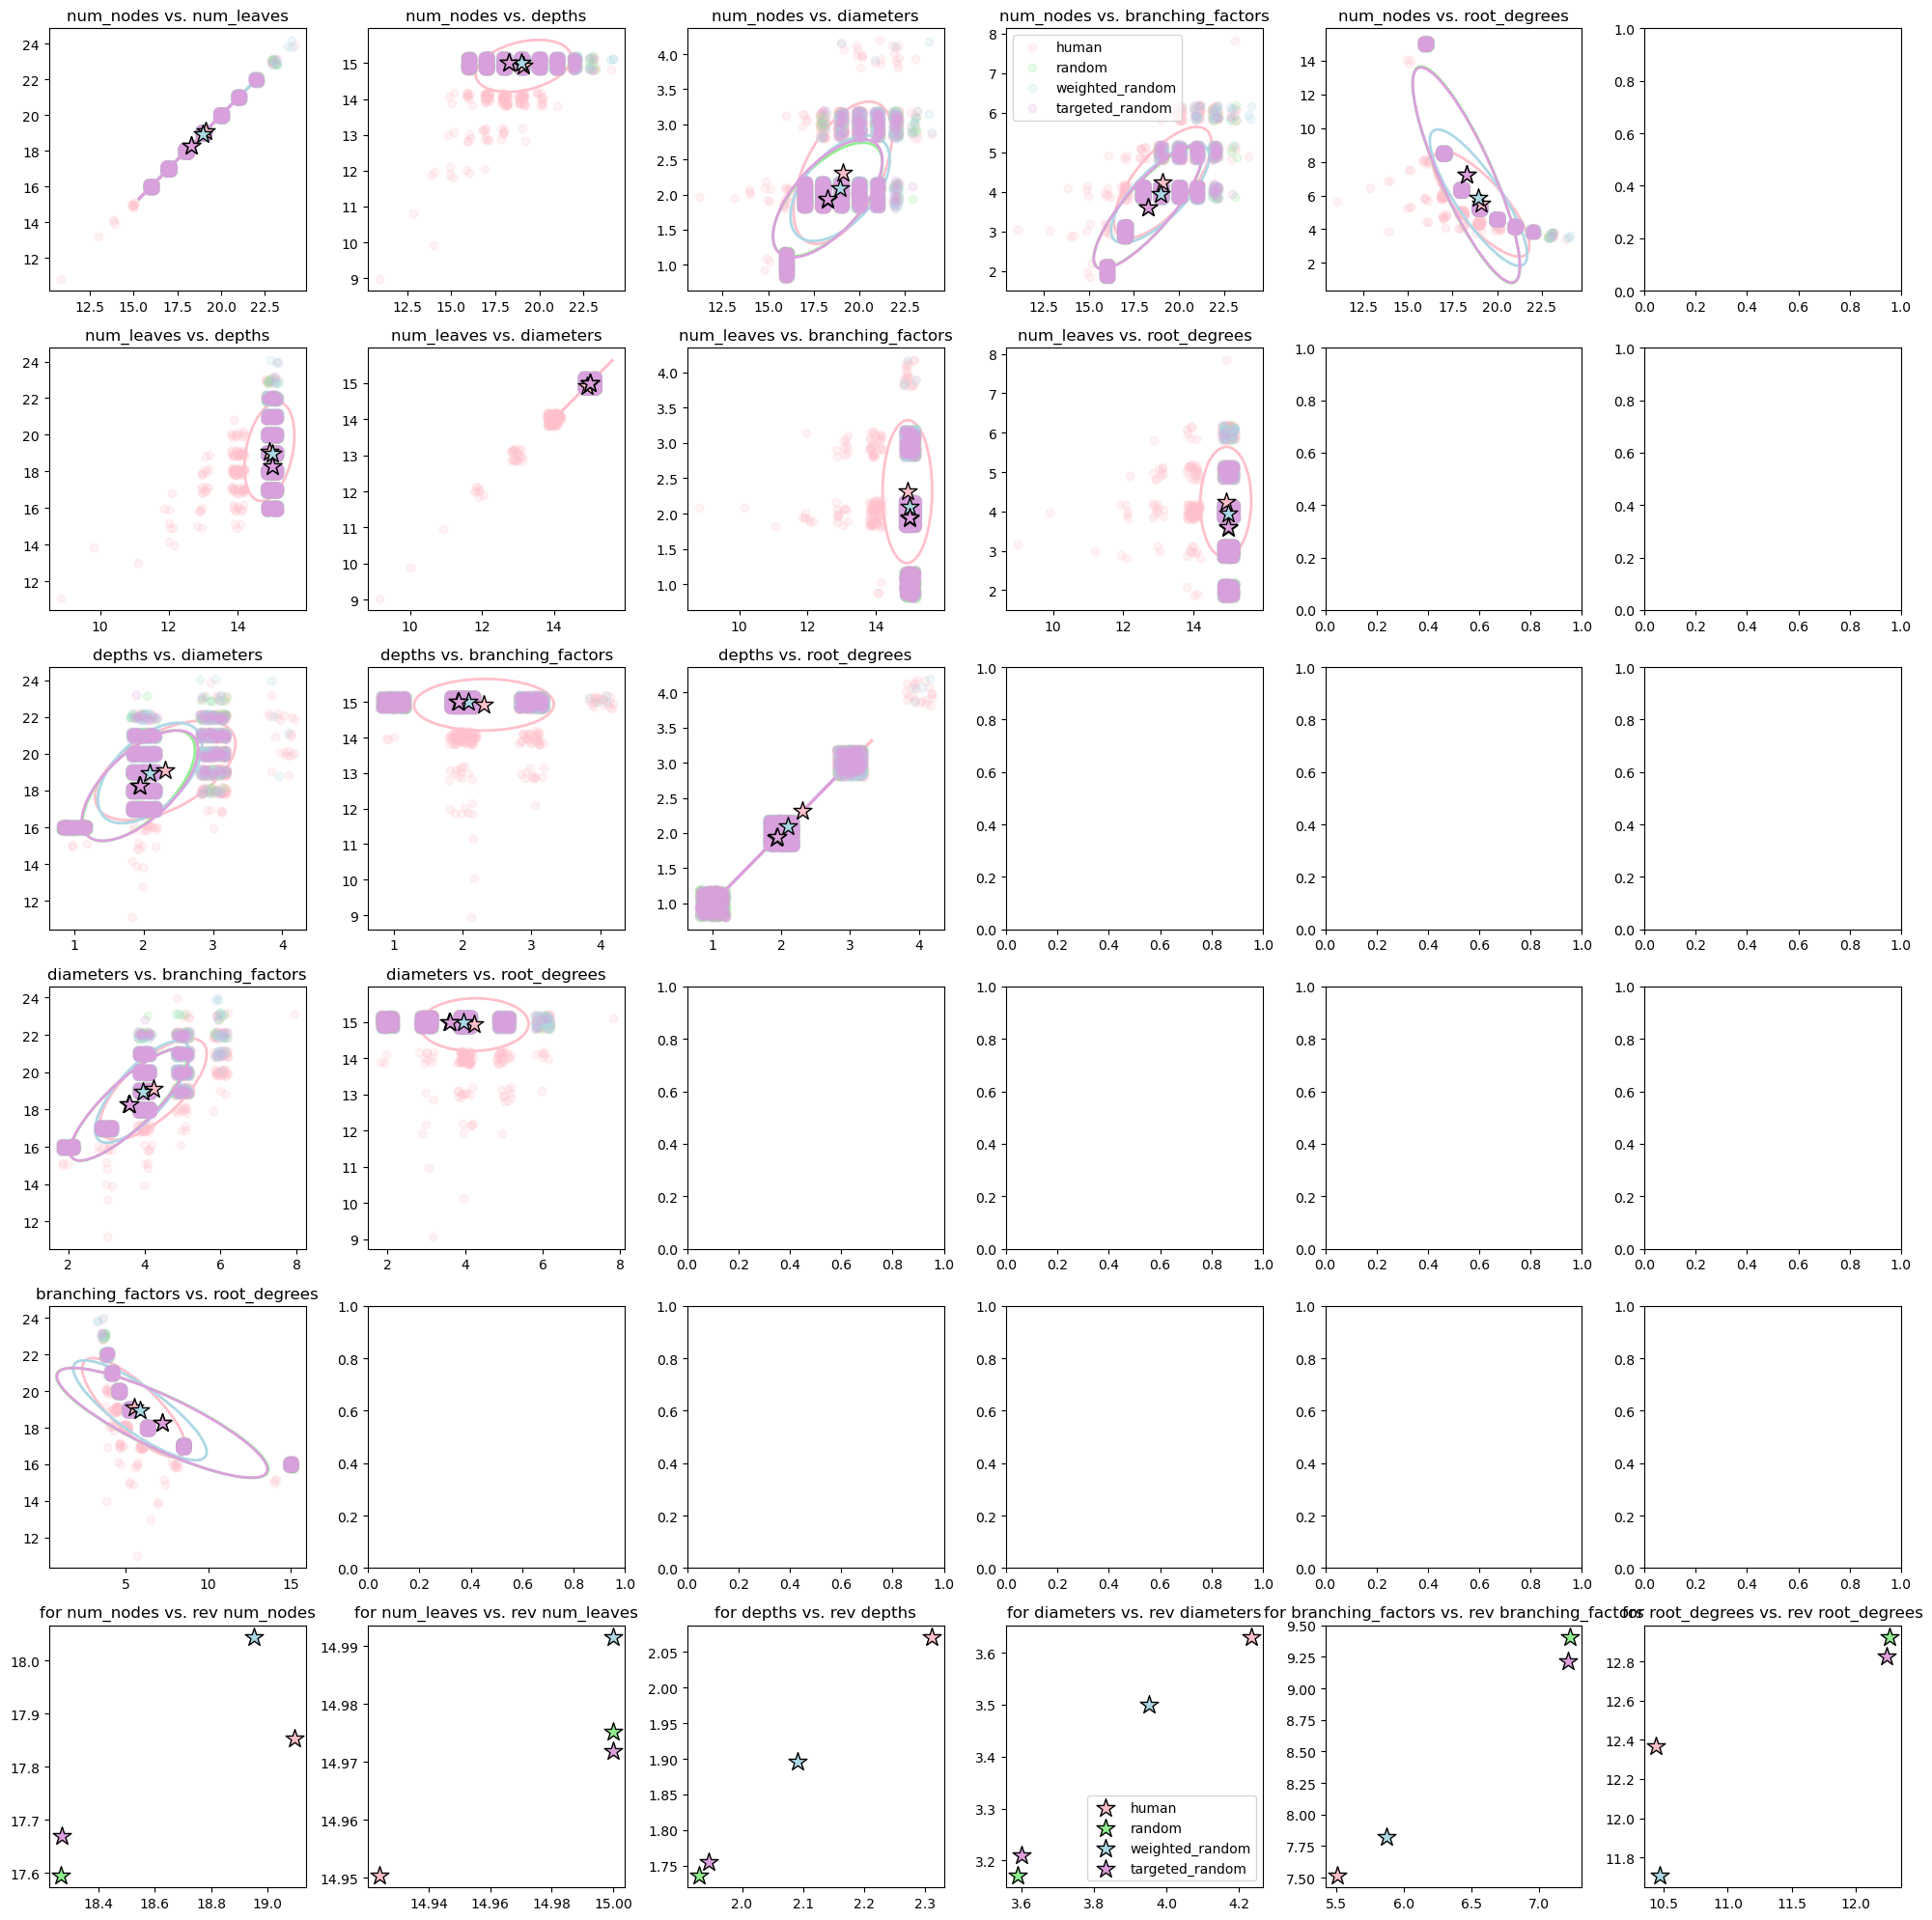

In [ ]:
# Plot by all sorts of things!!
colors = ["pink", "lightgreen", "lightblue", "plum", "red", "orange", "green", "black"]
feature_names = [
    "num_nodes",
    "num_leaves",
    "depths",
    "diameters",
    "branching_factors",
    "root_degrees",
]
fig, axes = plt.subplots(6, 6, figsize=(20, 20))

for i, group in enumerate(["human", "random", "weighted_random", "targeted_random"]):
    rev_trees = [
        G
        for node in most_common_rev_flow_tree_dict
        for G in most_common_rev_flow_tree_dict[node][group]
    ]
    rev_features = np.array([extract_tree_features(G, 0) for G in rev_trees])
    # print(rev_features)
    for_trees = [
        G
        for node in most_common_flow_tree_dict
        for G in most_common_flow_tree_dict[node][group]
    ]
    for_features = np.array([extract_tree_features(G, 0) for G in for_trees])

    # plot_n_trees(rev_trees[:10])
    # plot_n_trees(for_trees[:10])

    for ii, feats in enumerate(
        [
            for_features,
        ]
    ):
        for j, feat1_name in enumerate(feature_names):
            for k, feat2_name in enumerate(feature_names[j + 1 :]):
                jitter_width = 0.2
                n_group = len(feats[:, j])

                axes[j, k].scatter(
                    feats[:, j]
                    + np.random.uniform(-jitter_width, jitter_width, size=n_group),
                    feats[:, k]
                    + np.random.uniform(-jitter_width, jitter_width, size=n_group),
                    c=colors[i + 4 * ii],
                    marker="o",
                    facecolors="none",
                    alpha=0.2,
                    label=group,
                )
                axes[j, k].scatter(
                    feats[:, j].mean(),
                    feats[:, k].mean(),
                    c=colors[i + 4 * ii],
                    alpha=1,
                    s=200,
                    marker="*",
                    edgecolors="black",
                    zorder=10,
                )
                confidence_ellipse(
                    feats[:, j],
                    feats[:, k],
                    axes[j, k],
                    n_std=2.0,
                    edgecolor=colors[i + 4 * ii],
                    facecolor="none",
                    linewidth=2,
                )
                axes[j, k].set_title(f"{feat1_name} vs. {feat2_name}")

    for j, feat_name in enumerate(feature_names):
        # axes[j, k].scatter(feats[j], feats[k], c=colors[i + 4 * ii], label=group)
        axes[-1, j].scatter(
            for_features[:, j].mean(),
            rev_features[:, j].mean(),
            c=colors[i + 4 * ii],
            alpha=1,
            s=200,
            marker="*",
            edgecolors="black",
            zorder=10,
            label=group,
        )
        # confidence_ellipse(
        #     feats[j],
        #     feats[k],
        #     axes[j, k],
        #     n_std=2.0,
        #     edgecolor=colors[i + 4 * ii],
        #     facecolor="none",
        #     linewidth=2,
        # )
        axes[-1, j].set_title(f"for {feat_name} vs. rev {feat_name}")

axes[0, 3].legend()
axes[-1, 3].legend()
plt.tight_layout()
plt.show()


### PCA Analysis

In [42]:
## feature pca
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

for_features_dict = {}
rev_features_dict = {}
labels_dict = {}
trees_dict = {}

for group in ["human", "random", "weighted_random", "targeted_random"]:
    rev_trees = [
        G
        for node in most_common_rev_flow_tree_dict
        for G in most_common_rev_flow_tree_dict[node][group]
    ]
    trees = [
        G
        for node in most_common_flow_tree_dict
        for G in most_common_flow_tree_dict[node][group]
    ]

    rev_features = np.array(
        [
            extract_tree_features(G, 0)
            for node in most_common_rev_flow_tree_dict
            for G in most_common_rev_flow_tree_dict[node][group]
        ]
    )
    features = np.array(
        [
            extract_tree_features(G, 0)
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )
    rev_labels = np.array(
        [
            "rev-"
            + group  # "landmark" if node in outdegree_landmarks else "non-landmark"
            for node in most_common_rev_flow_tree_dict
            for G in most_common_rev_flow_tree_dict[node][group]
        ]
    )
    labels = np.array(
        [
            group  # "landmark" if node in outdegree_landmarks else "non-landmark"
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )

    for_features_dict[group] = [f[:-1] for f in features if True]  # f[0] in [18]]
    rev_features_dict[group] = [f[:-1] for f in rev_features if True]  # f[0] in [18]]
    labels_dict[group] = labels
    # labels_dict["rev-"+group] = rev_labels
    trees_dict[group] = trees
    # trees_dict["rev-"+group] = rev_trees

all_features = np.concatenate(
    list(for_features_dict.values()) + list(rev_features_dict.values())
)

scaler = StandardScaler()
all_scaled = scaler.fit_transform(all_features)

pca = PCA(n_components=3)  # 0.95

X_pca = pca.fit_transform(all_scaled)

print("Original shape:", all_scaled.shape)
print("Transformed shape:", X_pca.shape)
print("Number of components chosen:", pca.n_components_)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.sum(pca.explained_variance_ratio_))

Original shape: (19994, 5)
Transformed shape: (19994, 3)
Number of components chosen: 3
Explained variance ratio: [0.70141072 0.20424036 0.05677013]
Cumulative explained variance: 0.9624212118127983


[[ 0.9068813   0.15058717 -0.3431039 ]
 [-0.02317106  0.99655772  0.07344997]
 [ 0.90846014 -0.05945005  0.38960782]
 [ 0.97601094 -0.02874745  0.04106672]
 [-0.95203007  0.0329901   0.08525814]]
human 2500
random 2500
weighted_random 2500
targeted_random 2500
human 2500
random 2498
weighted_random 2498
targeted_random 2498


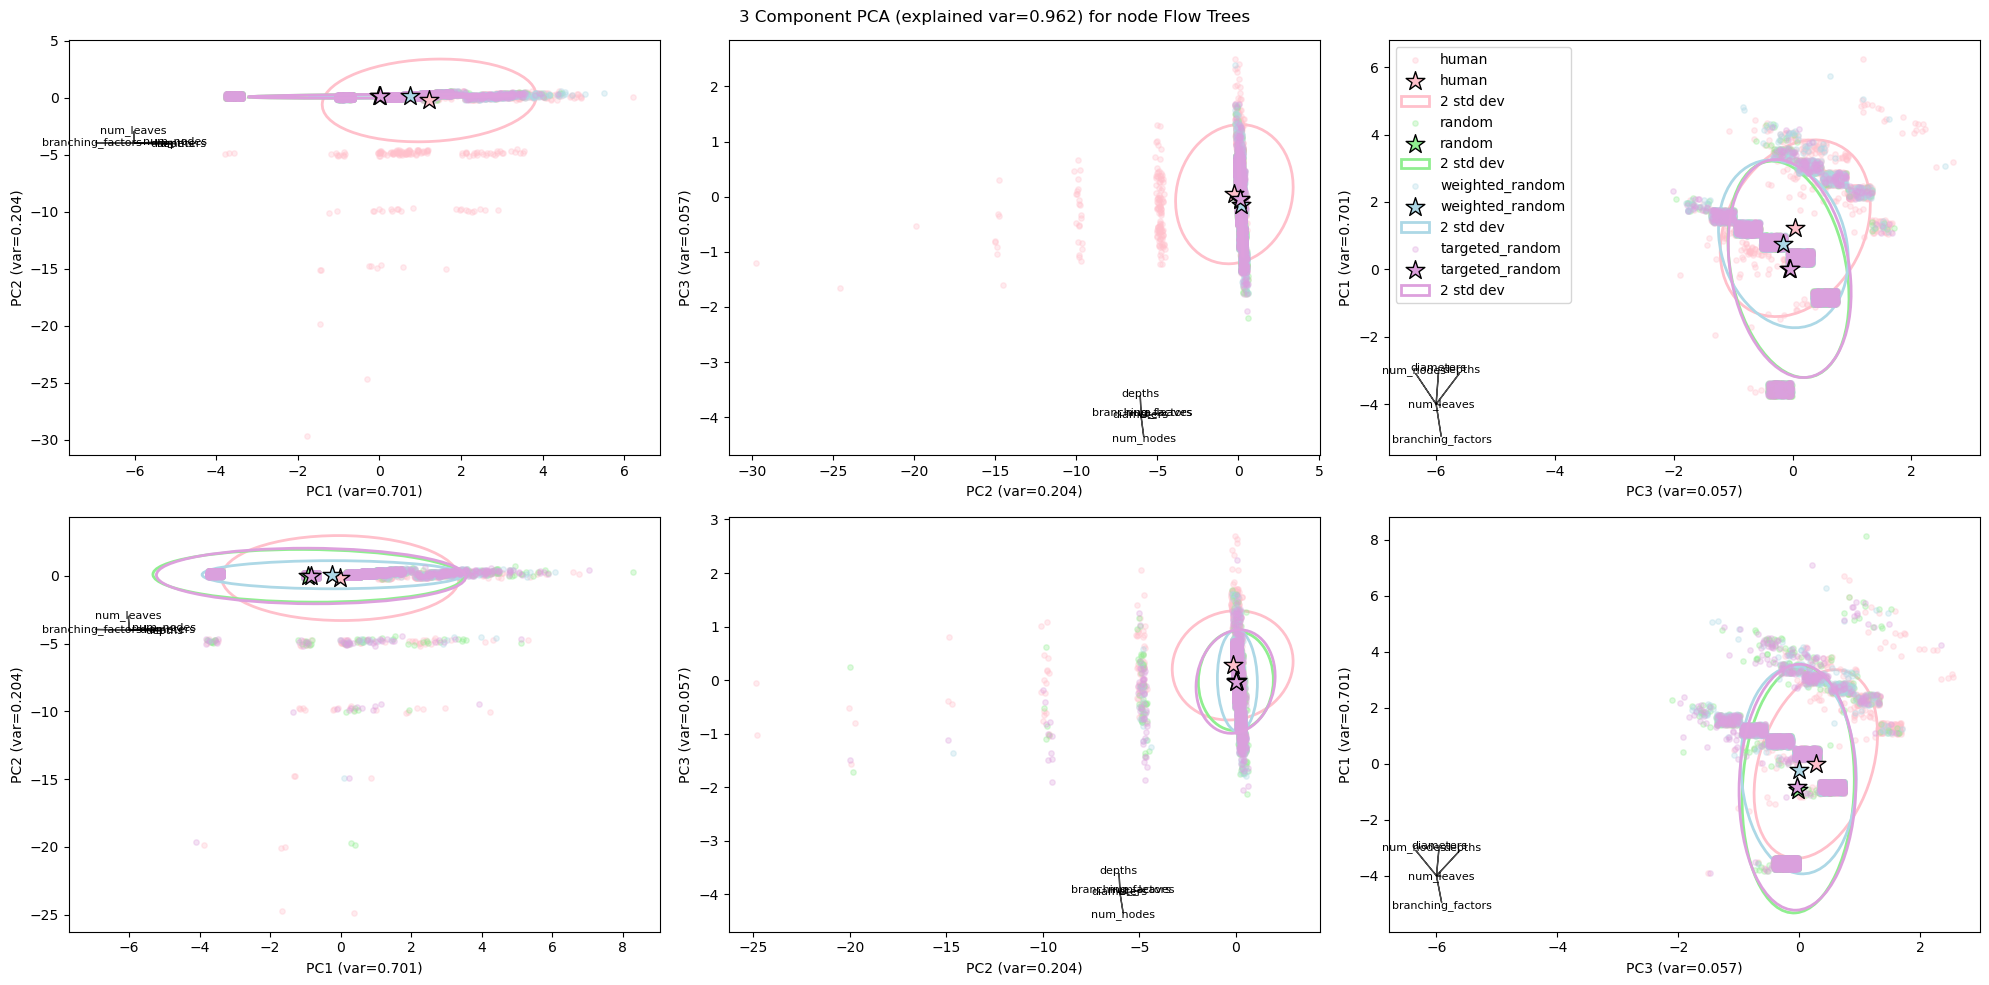

+++++++++++++++++++++++++++
forward
+++++++++++++++++++++++++++
num_nodes
mean\_{h}=19.10, mean\_{random}=18.26
var\_{h}=1.83, var\_{random}=2.25
t=20.533, p=0.000
levene=39.489, p=0.000
num_leaves
mean\_{h}=14.92, mean\_{random}=15.00
var\_{h}=0.13, var\_{random}=0.00
t=-10.464, p=0.000
levene=109.496, p=0.000
depths
mean\_{h}=2.31, mean\_{random}=1.93
var\_{h}=0.26, var\_{random}=0.16
t=29.433, p=0.000
levene=182.356, p=0.000
diameters
mean\_{h}=4.23, mean\_{random}=3.59
var\_{h}=0.49, var\_{random}=0.59
t=31.012, p=0.000
levene=14.230, p=0.000
branching_factors
mean\_{h}=5.50, mean\_{random}=7.23
var\_{h}=2.45, var\_{random}=10.28
t=-24.167, p=0.000
levene=446.342, p=0.000
pc1
mean\_{h}=1.22, mean\_{random}=0.00
var\_{h}=1.72, var\_{random}=2.58
t=29.425, p=0.000
levene=18.852, p=0.000
pc2
mean\_{h}=-0.25, mean\_{random}=0.12
var\_{h}=3.29, var\_{random}=0.01
t=-10.238, p=0.000
levene=109.246, p=0.000
pc3
mean\_{h}=0.05, mean\_{random}=-0.07
var\_{h}=0.40, var\_{random}=0.26
t=7.028

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
print(loadings)
colors = ["pink", "lightgreen", "lightblue", "plum", "red", "orange", "green", "black"]
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

ccs = ["red", "purple", "blue", "green", "yellow", "orange", "black", "grey"]
for jj, features_dict in enumerate([for_features_dict, rev_features_dict]):
    for j, group in enumerate(features_dict):
        features = features_dict[group]
        print(group, len(features))
        # labels = labels_dict[group]

        scaled_features = scaler.transform(features)
        featuers_pca = pca.transform(scaled_features)

        for i in range(3):
            ax = axes[jj, i]
            jitter_width = 0.2
            n_group = len(features)

            ax.scatter(
                featuers_pca[:, i]
                + np.random.uniform(-jitter_width, jitter_width, size=n_group),
                featuers_pca[:, (i + 1) % 3]
                + np.random.uniform(-jitter_width, jitter_width, size=n_group),
                c=colors[j],
                alpha=0.3,
                s=15,
                label=group,
            )

            ax.scatter(
                featuers_pca[:, i].mean(),
                featuers_pca[:, (i + 1) % 3].mean(),
                c=colors[j],
                alpha=1,
                s=200,
                marker="*",
                edgecolors="black",
                label=group,
                zorder=10,
            )

            confidence_ellipse(
                featuers_pca[:, i],
                featuers_pca[:, (i + 1) % 3],
                ax,
                n_std=2.0,
                edgecolor=colors[j],
                facecolor="none",
                linewidth=2,
                label="2 std dev",
            )

    for i in range(3):
        # Plot the loadings as arrows
        for j, feature in enumerate(feature_names[:-1]):
            axes[jj, i].arrow(
                -6, -4, loadings[j, i], loadings[j, (i + 1) % 3], color="k", alpha=0.7
            )
            axes[jj, i].annotate(
                feature,
                (-6 + loadings[j, i] * 1.1, -4 + loadings[j, (i + 1) % 3] * 1.1),
                color="k",
                fontsize=8,
                ha="center",
                va="center",
            )

        axes[jj, i].set_xlabel(
            f"PC{i + 1} (var={pca.explained_variance_ratio_[i]:0.3f})"
        )
        axes[jj, i].set_ylabel(
            f"PC{(i + 1) % 3 + 1} (var={pca.explained_variance_ratio_[(i + 1) % 3]:0.3f})"
        )

    axes[0, 2].legend()

plt.suptitle(
    f"3 Component PCA (explained var={np.sum(pca.explained_variance_ratio_):0.3f}) for node Flow Trees"
)
plt.tight_layout()
plt.show()


group = "human"
for jj, features_dict in enumerate([for_features_dict, rev_features_dict]):
    print("+++++++++++++++++++++++++++")
    print("forward" if jj == 0 else "reverse")
    print("+++++++++++++++++++++++++++")
    for other_group in ["random", "weighted_random", "targeted_random"]:
        feats1 = np.array(features_dict[group])
        feats2 = np.array(features_dict[other_group])
        for i, feat_name in enumerate(feature_names[:-1]):
            print(feat_name)
            print(
                f"mean\\_{{h}}={feats1[:, i].mean():0.2f}, mean\\_{{{other_group}}}={feats2[:, i].mean():0.2f}"
            )
            print(
                f"var\\_{{h}}={feats1[:, i].var():0.2f}, var\\_{{{other_group}}}={feats2[:, i].var():0.2f}"
            )

            t, p = stats.ttest_ind(feats1[:, i], feats2[:, i])
            print(f"t={t:0.3f}, p={p:0.3f}")
            stat, p = stats.levene(feats1[:, i], feats2[:, i])
            print(f"levene={stat:0.3f}, p={p:0.3f}")

        scaled_features1 = scaler.transform(feats1)
        features_pca1 = pca.transform(scaled_features1)
        scaled_features2 = scaler.transform(feats2)
        features_pca2 = pca.transform(scaled_features2)
        for i in range(3):
            print(f"pc{i + 1}")
            print(
                f"mean\\_{{h}}={features_pca1[:, i].mean():0.2f}, mean\\_{{{other_group}}}={features_pca2[:, i].mean():0.2f}"
            )
            print(
                f"var\\_{{h}}={features_pca1[:, i].var():0.2f}, var\\_{{{other_group}}}={features_pca2[:, i].var():0.2f}"
            )

            t, p = stats.ttest_ind(features_pca1[:, i], features_pca2[:, i])
            print(f"t={t:0.3f}, p={p:0.3f}")
            stat, p = stats.levene(features_pca1[:, i], features_pca2[:, i])
            print(f"levene={stat:0.3f}, p={p:0.3f}")

# p
# num_nodes,
# num_leaves,
# depth,
# diameter,
# bf,
# rd,

# [[ 0.         -0.         -0.        ]
#  [ 0.94820751  0.2662639   0.16660896]
#  [-0.45700125  0.86253202 -0.21816858]
#  [-0.82148689  0.15351027  0.54953933]
#  [ 0.93421395  0.28667037  0.20740022]]